In [2]:
import pandas as pd
import numpy as np
import dspy
from typing import Literal, List
import json
dspy.configure_cache(
    enable_disk_cache=False,
    enable_memory_cache=False,
)

In [3]:
class CLassifyThreethemes(dspy.Signature):
        """
       You are a world-leading expert in medical literature analysis, specializing in Lyme disease and its associated controversies. The current literature on this topic is polarised and the text below describes the problem statement that was used for classifying abstracts based on their explicit or implict position on this controversy:
 
         "Some medical experts argue that post-treatment symptoms, experienced by a subset of patients after completing standard antibiotic therapy, can be attributed to what they define as Post-Treatment Lyme Disease Syndrome (PTLDS). According to some health organisations, these symptoms—ranging from fatigue to cognitive impairment—are likely caused by immune responses or tissue damage, rather than persistent infection. PTLDS concerns patients who experience persistent symptoms for at least six months after the completion of recommended treatment for Lyme disease.
         
         Conversely, other organisations advocate for the recognition of chronic Lyme disease (CLD), contending that ongoing infection or immune dysfunction may be responsible for these symptoms and recommend extended antibiotic regimens, pointing to contested evidence of patient improvement. CLD is a broader term that encompasses a range of unexplained symptoms that patients attribute to a persistent Lyme disease infection that survives recommended treatment.  Both PTLDS and CLD involve persistent symptoms, such as fatigue, pain, and neurological issues, and both face with diagnostic difficulties due to nonspecific symptoms and lack of clear biomarkers, contributing to ongoing debates in the medical community."
         
         The original task was to classify abstracts into one of the following criteria and to provide a justification for the classification:
         **Definitions and criteria used for original classifications**:
         1. **Supports PTLDS**:
            - Attributes persistent symptoms after successful Lyme disease treatment to other factors like immune dysfunction, chronic fatigue syndrome, or depression.
            - Opposes the use of prolonged or repeated antibiotic treatments for PTLDS.
            - Suggests or implies that CLD lacks scientific support.
         
         2. **Supports CLD**:
            - Suggests that symptoms result from ongoing or active *Borrelia burgdorferi* infection after standard treatment, often cited as requiring extended antibiotic therapy.
            - Suggests that persistent symptoms may require prolonged or repeated antibiotic treatment.
         
         3. **Neutral**:
            - Presents balanced arguments without clearly supporting or refuting either PTLDS or CLD.
            - Discusses aspects of Lyme disease that relate to both sides of the PTLDS and CLD debate without taking a clear stance.
            - Contains no explicit or implicit stance supporting or refuting PTLDS or CLD.
         
         Your TASK now is to examine the justifications generated from the above step for classifying abstracts into the three categories, together with analyzing the abstract itself, and then your TASK is to **reframe** each pair of justification with the accompanying abstract in terms of **three most relevant overarching themes** that they fall into from the list below. Choose three themes that best reflect the core arguments or discussion in that justification.
         
         ### Overarching Themes
         
         1. **Active Infection vs. Post-Infectious Immune Activity**  
            Focuses on whether persistent symptoms are linked to active Borrelia burgdorferi infection or post-infectious immunological phenomena.
         
         2. **Diagnostic Complexity and Uncertainty**  
            Addresses challenges in diagnosing Lyme disease accurately, including testing limitations, the risk of misdiagnosis, and non-specific clinical presentations.
         
         3. **Therapeutic Controversies and Antibiotic Efficacy**  
            Encompasses debates over prolonged antibiotic regimens, extended or novel treatment strategies, and conflicting guideline recommendations.
 
         4. **Immune Dysregulation and Autoimmune Mechanisms**  
            Highlights the role of maladaptive immune responses, autoantibody production, and inflammatory cascades that might drive persistent symptoms.
         
         5. **Neurocognitive and Neuropsychiatric Manifestations**  
            Covers memory issues, neuropathic pain, panic attacks, and other neurological or psychiatric presentations related to Lyme disease.
         
         6. **Patient-Centered Experiences and Advocacy**  
            Explores patient narratives of chronic disability, frustration in seeking diagnosis or care, and the broader psychosocial context influencing illness experiences.
         
         7. **Sociocultural and Ethical Factors**  
            Looks at the influence of advocacy groups, media coverage, legal disputes, and ethical dilemmas around diagnosing or treating chronic Lyme disease.
         
         8. **Mechanisms of Pathogen Persistence and Biofilm Formation**  
            Focuses on arguments and evidence for persister cells, Borrelia biofilms, and other microbial survival strategies that might warrant further or alternative therapies.
         
         ### Task Details
         
         1. **Re-read the Justification and Abstract**  
            - You have already classified each abstract regarding CLD/PTLDS, but now you must identify which **three** of the above **eight themes** best align with the justification and reasoning provided, and the text's focus.  
         
         2. **Determine the Dominant Themes**  
            - From the eight themes, select the three that most strongly match the arguments or discussion points in the justification.  
            - Consider explicit statements (e.g., extended antibiotic therapy, persistent infection) or implicit context (e.g., patient advocacy).

            - **paper_title**: the title of the the abstract. 
            - **chosen_themes**: exactly three theme labels from the list of eight.  
         
         **Themes to choose from**:  
         1. Active Infection vs. Post-Infectious Immune Activity  
         2. Diagnostic Complexity and Uncertainty  
         3. Therapeutic Controversies and Antibiotic Efficacy  
         4. Immune Dysregulation and Autoimmune Mechanisms  
         5. Neurocognitive and Neuropsychiatric Manifestations  
         6. Patient-Centered Experiences and Advocacy  
         7. Sociocultural and Ethical Factors  
         8. Mechanisms of Pathogen Persistence and Biofilm Formation  
         
         
         ### Tips and Additional Instructions
         
         - **Stay Within the Eight Themes**: Do not invent new themes or alter the definitions.  
         - **Pick Exactly Three**: Even if the justification touches on multiple aspects, select only the three strongest matches.  
         - **Use the Text’s Own Evidence**: Ground your reasoning in details from the justification (e.g., references to antibiotic failure, immune markers, patient frustration, testing limitations). But only output the json object  
         - **Avoid Introducing Old Criteria**: While each abstract was originally classified for PTLDS/CLD, your sole task now is selecting three of the eight themes above only.
                                                
        """
    
        abstract: str = dspy.InputField(
            desc="Number of themes from the provided list that are relevant to the abstract"
        )
        

        themes: List[str] = dspy.OutputField(desc="list of 3 themes")

In [4]:
import json
import pandas as pd
with open("../../results/classification/ensembled_classification_results_detailed_filtered.json", "r") as f:
    filtered_data = json.load(f)["results"]

In [5]:
import json
import os
# student_llm_string = 'openrouter/x-ai/grok-4-fast'
# results_path = "../../results/thematic_classification/three_theme_classification_results_grok_original.json"
# screener_results_path = "../../classifier/thematic_classification/screener_classification_results_grok_original.json"
student_llm_string = 'openrouter/google/gemini-2.0-flash-001'
results_path = "../../results/thematic_classification/three_theme_classification_results_gemini_original.json"
screener_results_path = "../../classifier/thematic_classification/three_theme_classification_results_gemini_original.json"
results_path_save = "../../results/thematic_classification/three_theme_classification_results_gemini_original.jsonl"
# student_llm_string = "openai/gpt-5-mini"
# results_path = "../../results/thematic_classification/three_theme_classification_results_gpt_original_gepa_reflacor_gpt-4omini.json"
# screener_results_path = "../../classifier/thematic_classification/three_theme_classification_results_gpt_original_reflacor_gpt-4omini.json"
# results_path_save = "../../results/thematic_classification/three_theme_classification_results_gpt_original_gepa_reflacor_gpt-4omini.jsonl"
API_KEY = os.getenv("openrouter_api_key")
student_lm = dspy.LM(
    model=student_llm_string,       # e.g. "openrouter/google/gemini-2.0-flash-001"
    api_base="https://openrouter.ai/api/v1",
    api_key=API_KEY,
    # (plus any model_params like temperature, max_tokens, etc)
    # temperature=1.0, top_p=1.0, seed=42
    temperature=1.0, max_tokens = 350000,
)
dspy.configure(lm=student_lm)

theme_classifier = dspy.ChainOfThought(CLassifyThreethemes)

In [6]:
theme_classifier = dspy.ChainOfThought(CLassifyThreethemes)
theme_classifier.load(screener_results_path)
counter = 0
print(len(filtered_data))
for item in filtered_data:
    abstract = item['abstract']
    # print(abstract)
    theme_list = theme_classifier(abstract=abstract)
    if theme_list["themes"] is None:
        print("Retrying classification for abstract:", abstract)
        theme_list = theme_classifier(abstract=abstract)
        if theme_list["themes"] is None:
            print("Failed to classify themes for abstract:", abstract)
            theme_list = {"themes": []}
    with open(results_path_save, "a") as f:
        json_line = {
            "abstract": abstract,
            "themes": theme_list["themes"]
        }
        f.write(json.dumps(json_line) + "\n")       
    # list_themes.append({"abstract": abstract, 
    #                       "thmes": theme_list["themes"]})
    print(f"Processed {counter} abstracts", end='\r')
    counter += 1
with open(results_path_save, "r") as f:
    test_results = [json.loads(line) for line in f]
    
with open(results_path, "w") as f:
    json.dump(test_results, f, indent=4)

1373


{'Active Infection vs. Post-Infectious Immune Activity': 1084, 'Diagnostic Complexity and Uncertainty': 1086, 'Therapeutic Controversies and Antibiotic Efficacy': 750, 'Neurocognitive and Neuropsychiatric Manifestations': 382, 'Immune Dysregulation and Autoimmune Mechanisms': 280, 'Sociocultural and Ethical Factors': 105, 'Patient-Centered Experiences and Advocacy': 302, 'Mechanisms of Pathogen Persistence and Biofilm Formation': 127}


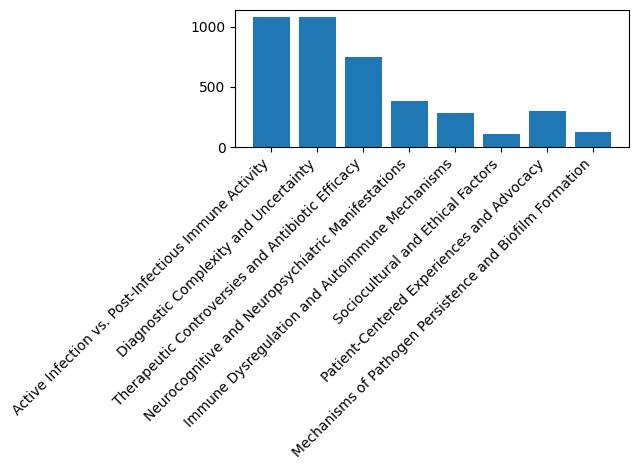

In [10]:
class_counte = {}
for item in test_results:
    classes = item['themes']
    for cls in classes:
        if cls not in class_counte:
            class_counte[cls] = 0
        class_counte[cls] += 1
    abstract = item['abstract']
    # check if dublicate abstract is in list
    # if abstract in [x['abstract'] for x in test_results if x != item]:
    #     print("Duplicate abstract found:", abstract)
print(class_counte)
# show as pltot bar chart
import matplotlib.pyplot as plt
plt.bar(class_counte.keys(), class_counte.values())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()